# Menelusuri Kualitas Data PM2.5 Jakarta

Notebook ini digunakan untuk melakukan pengecekan awal dan eksplorasi data PM2.5 dari dataset master hasil penggabungan data SPKU dan weather.

Fokus utama notebook ini adalah memahami tiga hal penting:

1. Seberapa besar missing value pada kolom `pm25`.
2. Bagaimana pola harian atau **diurnal cycle** PM2.5.
3. Bagaimana pola musiman atau **seasonal pattern** PM2.5.

Notebook ini juga membandingkan dua pendekatan EDA:

| Pendekatan | Penjelasan | Tujuan |
|---|---|---|
| Observed only | Baris dengan `pm25` missing dibuang | Melihat pola berdasarkan data asli yang benar-benar tersedia |
| Visual filled | Missing value diisi dengan interpolasi, lalu bfill/ffill di tepi | Membantu visualisasi agar pola time series lebih utuh |

Catatan penting: pendekatan **visual filled** digunakan untuk eksplorasi dan visualisasi, bukan otomatis berarti data hasil filling boleh langsung dipakai sebagai target modeling. Untuk modeling, strategi imputasi perlu ditentukan lebih hati-hati agar tidak menimbulkan bias.

## Membuka Dataset Master dan Memeriksa Struktur Awal

Cell ini membaca file utama:

`dataset_master_spku_weather.csv`

File tersebut merupakan dataset master hasil proses sebelumnya, yaitu gabungan antara data kualitas udara SPKU dan data cuaca dari Open-Meteo.

Kode yang dijalankan melakukan tiga hal utama:

1. Mengimpor library dasar seperti `pandas`, `numpy`, dan `matplotlib`.
2. Membaca dataset menggunakan `pd.read_csv()`.
3. Menampilkan struktur dataset menggunakan `df_sanity.info()`.

Output `info()` berguna untuk melihat:

| Informasi | Fungsi |
|---|---|
| Jumlah baris | Mengetahui banyaknya observasi dalam dataset |
| Jumlah kolom | Mengetahui banyaknya variabel yang tersedia |
| Tipe data | Mengecek apakah kolom sudah terbaca sebagai numerik, object, atau datetime |
| Jumlah non-null | Mengidentifikasi kolom yang memiliki missing value |

Pada tahap ini, pengecekan struktur data penting karena sebelum EDA dilakukan, kita perlu memastikan dataset sudah terbaca dengan benar dan kolom-kolom utama seperti `pm25`, `datetime`, `station_slug`, `hour_num`, dan `month` tersedia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "dataset_master_spku_weather.csv"

df_sanity = pd.read_csv(DATA_PATH)
df_sanity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155880 entries, 0 to 155879
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   datetime              155880 non-null  object 
 1   date                  155880 non-null  object 
 2   hour                  155880 non-null  object 
 3   station_id            155880 non-null  int64  
 4   station_slug          155880 non-null  object 
 5   station_name          155880 non-null  object 
 6   lokasi                155880 non-null  object 
 7   pm25                  80244 non-null   float64
 8   pm10                  78091 non-null   float64
 9   so2                   83726 non-null   float64
 10  co                    83916 non-null   float64
 11  o3                    83955 non-null   float64
 12  no2                   83466 non-null   float64
 13  hc                    0 non-null       float64
 14  kategori              84546 non-null   object 
 15  

## Membaca Pola Missing Value pada PM2.5

Cell ini menghitung missing value pada kolom `pm25` dari beberapa sudut pandang, yaitu secara keseluruhan, per stasiun, per jam, dan per bulan.

### Missing PM2.5 secara keseluruhan

Output menunjukkan bahwa missing ratio `pm25` adalah sekitar:

`0.4852`

Artinya, sekitar **48,52% data PM2.5 masih kosong**. Ini merupakan proporsi missing value yang cukup besar, sehingga strategi penanganan missing value menjadi bagian penting sebelum data digunakan untuk modeling.

### Missing PM2.5 per stasiun

Missing value juga dihitung berdasarkan `station_slug`.

| Stasiun | Missing Ratio PM2.5 |
|---|---:|
| `dki1-bundaran-hi` | 0.463979 |
| `dki2-kelapa-gading` | 0.459007 |
| `dki3-jagakarsa` | 0.460354 |
| `dki4-lubang-buaya` | 0.469143 |
| `dki5-kebun-jeruk` | 0.573614 |

Dari hasil ini, `dki5-kebun-jeruk` memiliki missing ratio tertinggi, yaitu sekitar **57,36%**. Artinya, stasiun ini perlu diperhatikan lebih hati-hati karena ketersediaan data PM2.5-nya lebih rendah dibanding stasiun lain.

### Missing PM2.5 per jam

Missing value juga dicek berdasarkan `hour_num`. Hasilnya menunjukkan bahwa jam `00`, `01`, dan `02` memiliki missing ratio yang sangat tinggi, yaitu di atas **83%**.

Ini mengindikasikan bahwa missing PM2.5 tidak sepenuhnya acak. Ada pola kuat berdasarkan jam, sehingga missing value kemungkinan dipengaruhi oleh proses pencatatan, jadwal update data, atau ketersediaan data pada jam tertentu.

### Missing PM2.5 per bulan

Missing value juga bervariasi antarbulan. Beberapa bulan memiliki missing ratio lebih tinggi dibanding bulan lain. Hal ini penting karena jika missing value terkonsentrasi pada bulan tertentu, maka analisis seasonal dapat menjadi bias jika tidak ditangani dengan benar.

Secara keseluruhan, cell ini menunjukkan bahwa missing value pada `pm25` tidak bisa diabaikan. Missing value perlu dianalisis sebelum memilih strategi EDA dan modeling.

In [2]:
# Missing ratio PM2.5 overall
print("Missing ratio pm25:", df_sanity["pm25"].isna().mean())

# Missing ratio per station
missing_station = (
    df_sanity.groupby("station_slug")["pm25"]
    .apply(lambda s: s.isna().mean())
    .reset_index(name="pm25_missing_ratio")
)
print(missing_station)

# Missing ratio per hour
missing_hour = (
    df_sanity.groupby("hour_num")["pm25"]
    .apply(lambda s: s.isna().mean())
    .reset_index(name="pm25_missing_ratio")
)
print(missing_hour)

# Missing ratio per month
missing_month = (
    df_sanity.groupby("month")["pm25"]
    .apply(lambda s: s.isna().mean())
    .reset_index(name="pm25_missing_ratio")
)
print(missing_month)

Missing ratio pm25: 0.4852193995381062
         station_slug  pm25_missing_ratio
0    dki1-bundaran-hi            0.463979
1  dki2-kelapa-gading            0.459007
2      dki3-jagakarsa            0.460354
3   dki4-lubang-buaya            0.469143
4    dki5-kebun-jeruk            0.573614
    hour_num  pm25_missing_ratio
0          0            0.842648
1          1            0.843880
2          2            0.838645
3          3            0.464203
4          4            0.469284
5          5            0.458968
6          6            0.474057
7          7            0.461278
8          8            0.447729
9          9            0.427406
10        10            0.431717
11        11            0.426174
12        12            0.415704
13        13            0.418938
14        14            0.412471
15        15            0.416936
16        16            0.422479
17        17            0.419092
18        18            0.416474
19        19            0.414473
20        20    

## Visualisasi Missing Value PM2.5 Berdasarkan Jam

Cell ini membuat grafik batang untuk menampilkan missing ratio `pm25` berdasarkan jam dalam sehari.

Sumbu X menunjukkan `hour_num`, yaitu jam ke-0 sampai jam ke-23. Sumbu Y menunjukkan proporsi missing value pada jam tersebut.

Grafik ini membantu melihat apakah missing value tersebar merata sepanjang hari atau justru terkonsentrasi pada jam-jam tertentu.

Dari output sebelumnya, missing value terlihat sangat tinggi pada jam awal hari, terutama sekitar pukul 00.00 sampai 02.00. Hal ini penting karena jika model forecasting menggunakan fitur berbasis jam, maka pola missing berdasarkan jam perlu dipertimbangkan.

Kesimpulan utama dari grafik ini adalah:

| Temuan | Implikasi |
|---|---|
| Missing PM2.5 sangat tinggi pada jam 00.00–02.00 | Data pada dini hari perlu dicek lebih lanjut |
| Missing value tidak merata sepanjang hari | Missing tidak sepenuhnya acak |
| Ada jam tertentu yang lebih stabil datanya | Jam tersebut lebih aman untuk dianalisis secara observed-only |

Grafik ini menjadi dasar awal untuk menentukan apakah EDA sebaiknya dilakukan dengan membuang missing value atau dengan membuat versi visual filled untuk membantu pembacaan pola.

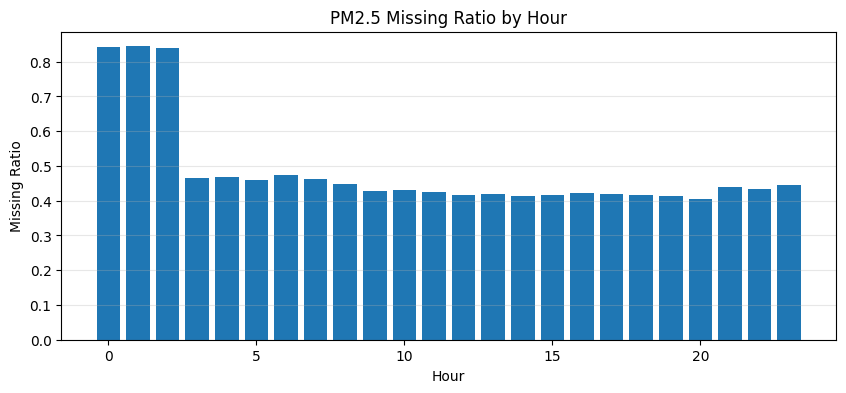

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(missing_hour["hour_num"], missing_hour["pm25_missing_ratio"])
plt.xlabel("Hour")
plt.ylabel("Missing Ratio")
plt.title("PM2.5 Missing Ratio by Hour")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# EDA PM2.5 dengan Data Asli yang Tersedia

Bagian ini melakukan eksplorasi PM2.5 menggunakan pendekatan **observed only**, yaitu hanya memakai baris yang memiliki nilai `pm25`.

Pada pendekatan ini, semua baris dengan `pm25` kosong dibuang terlebih dahulu. Tujuannya adalah agar analisis hanya berdasarkan data asli yang benar-benar tercatat, tanpa nilai hasil imputasi atau interpolasi.

Pendekatan ini cocok untuk menjawab pertanyaan:

1. Bagaimana pola PM2.5 berdasarkan data asli yang tersedia?
2. Stasiun mana yang memiliki rata-rata PM2.5 lebih tinggi?
3. Pada jam berapa PM2.5 cenderung naik atau turun?
4. Apakah ada pola musiman antara musim kering dan musim basah?

Kelebihan pendekatan ini adalah hasilnya tidak dipengaruhi oleh nilai buatan. Namun, kekurangannya adalah pola visual dapat menjadi bias jika missing value tidak tersebar secara merata.

## Menyiapkan Data Observed Only untuk EDA PM2.5

Cell ini membaca ulang dataset master, melakukan cleaning dasar, lalu membuat dataset khusus EDA dengan cara membuang baris yang tidak memiliki nilai `pm25`.

Tahapan utama pada cell ini adalah:

1. Membaca file `dataset_master_spku_weather.csv`.
2. Mengubah kolom `datetime` dan `date` menjadi format tanggal/waktu.
3. Mengubah kolom numerik menjadi tipe numerik menggunakan `pd.to_numeric()`.
4. Membatasi nilai ekstrem `pm25` dengan `clip(upper=500)`.
5. Membuat kolom waktu seperti `hour_num` dan `month` jika belum tersedia.
6. Mengecek keberadaan kolom `station_slug`.
7. Membuat dataframe `eda` dengan hanya mengambil baris yang memiliki nilai `pm25`.

Output cell menunjukkan:

| Informasi | Nilai |
|---|---:|
| Shape original | `(155880, 31)` |
| Shape EDA PM2.5 | `(80244, 31)` |
| Jumlah stasiun | `5` |

Artinya, dari total **155.880 baris**, hanya **80.244 baris** yang memiliki nilai PM2.5 dan digunakan untuk EDA observed only.

Rentang waktu data observed only adalah:

`2022-10-01 07:00:00` sampai `2026-04-21 23:00:00`

Karena missing value dibuang, rentang waktu awal bergeser dari jam 00.00 menjadi jam 07.00 pada tanggal awal. Ini menunjukkan bahwa pada awal periode terdapat beberapa jam yang tidak memiliki nilai PM2.5.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


DATA_PATH = "dataset_master_spku_weather.csv"   # ganti kalau nama file kamu beda


df = pd.read_csv(DATA_PATH)

# =========================
# 2) BASIC CLEANING
# =========================
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# pastikan kolom numerik
num_cols = [
    "pm25", "pm10", "so2", "co", "o3", "no2",
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "rain", "surface_pressure",
    "wind_speed_10m", "wind_direction_10m"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["pm25"] = df["pm25"].clip(upper=500)

# kalau hour_num belum ada, buat dari datetime
if "hour_num" not in df.columns:
    df["hour_num"] = df["datetime"].dt.hour

if "month" not in df.columns:
    df["month"] = df["datetime"].dt.month

if "station_slug" not in df.columns:
    raise ValueError("Kolom 'station_slug' tidak ditemukan.")

# pakai hanya baris yang punya target PM2.5
eda = df.dropna(subset=["pm25"]).copy()

print("Shape original :", df.shape)
print("Shape EDA PM2.5:", eda.shape)
print("Date range     :", eda["datetime"].min(), "->", eda["datetime"].max())
print("Stations       :", eda["station_slug"].nunique())

Shape original : (155880, 31)
Shape EDA PM2.5: (80244, 31)
Date range     : 2022-10-01 07:00:00 -> 2026-04-21 23:00:00
Stations       : 5


## Pola Harian PM2.5: Membaca Diurnal Cycle

Cell ini membuat grafik **diurnal cycle** PM2.5, yaitu pola rata-rata PM2.5 berdasarkan jam dalam satu hari.

Ada dua jenis rata-rata yang dihitung:

| Data | Penjelasan |
|---|---|
| `hourly_overall` | Rata-rata PM2.5 per jam untuk seluruh stasiun |
| `hourly_station` | Rata-rata PM2.5 per jam untuk masing-masing stasiun |

Grafik menampilkan kurva per stasiun dengan garis yang lebih tipis, lalu menampilkan rata-rata keseluruhan dengan garis yang lebih tebal.

Bagian `plt.axvspan(6, 15, alpha=0.15)` memberikan highlight visual pada rentang pukul 06.00 sampai 15.00. Rentang ini dapat dibaca sebagai proxy jam aktivitas pagi hingga siang.

Output grafik disimpan sebagai:

`eda_01_diurnal.png`

Dari visualisasi ini, kita dapat menilai apakah PM2.5 memiliki pola harian yang berulang. Jika pola per jam terlihat konsisten, maka fitur waktu seperti `hour_num`, indikator rush hour, dan lag jangka pendek berpotensi penting untuk model forecasting.

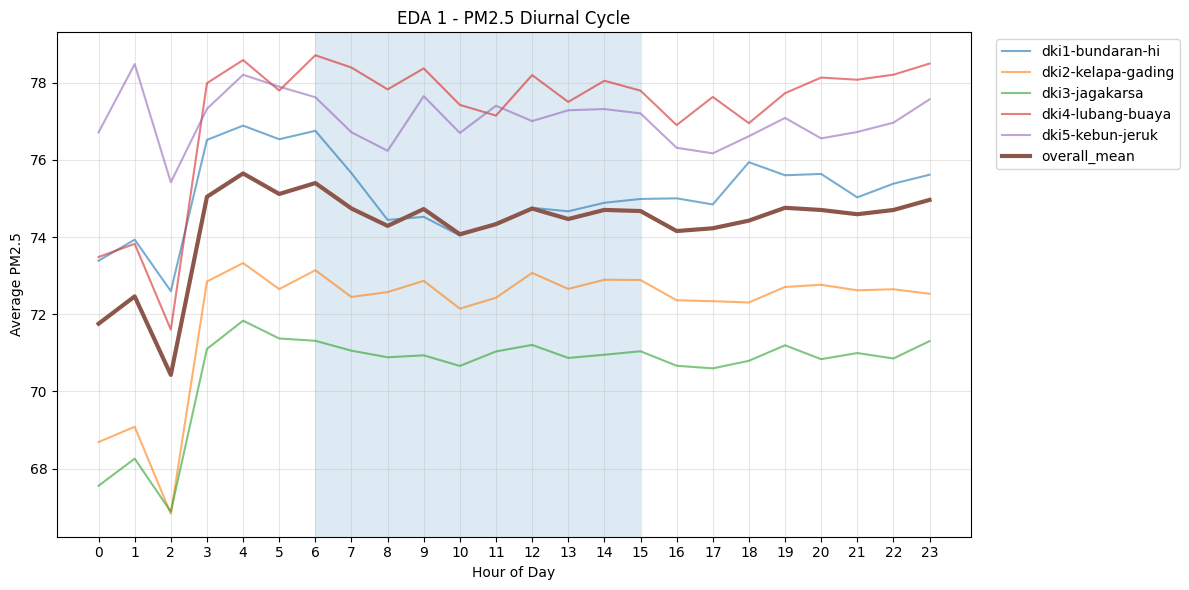

In [5]:
# =========================================================
# EDA 1: PM2.5 DIURNAL CYCLE
# Deliverable: eda_01_diurnal.png
# =========================================================

# overall hourly average
hourly_overall = (
    eda.groupby("hour_num", as_index=False)["pm25"]
    .mean()
    .sort_values("hour_num")
)

# hourly average per station
hourly_station = (
    eda.groupby(["station_slug", "hour_num"], as_index=False)["pm25"]
    .mean()
    .sort_values(["station_slug", "hour_num"])
)

plt.figure(figsize=(12, 6))

# plot per station tipis
for station, g in hourly_station.groupby("station_slug"):
    plt.plot(g["hour_num"], g["pm25"], linewidth=1.5, alpha=0.6, label=station)

# plot overall tebal
plt.plot(
    hourly_overall["hour_num"],
    hourly_overall["pm25"],
    linewidth=3,
    label="overall_mean"
)

# school hours overlay (proxy visual saja, bisa diubah)
# misalnya 06:00 - 15:00
plt.axvspan(6, 15, alpha=0.15)

plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.title("EDA 1 - PM2.5 Diurnal Cycle")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("eda_01_diurnal.png", dpi=200, bbox_inches="tight")
plt.show()

## Pola Bulanan PM2.5 Berdasarkan Sebaran Data Asli

Cell ini membuat analisis seasonal dengan membagi bulan ke dalam dua musim sederhana:

| Musim | Bulan |
|---|---|
| Wet | November, Desember, Januari, Februari, Maret, April |
| Dry | Mei, Juni, Juli, Agustus, September, Oktober |

Setelah itu, cell membuat boxplot PM2.5 per bulan menggunakan data asli yang memiliki nilai `pm25`.

Boxplot bulanan digunakan untuk melihat:

1. Median PM2.5 setiap bulan.
2. Sebaran nilai PM2.5 per bulan.
3. Perbedaan pola antara awal, tengah, dan akhir tahun.
4. Bulan-bulan dengan konsentrasi PM2.5 yang cenderung lebih tinggi.

Parameter `showfliers=False` digunakan agar outlier ekstrem tidak terlalu mendominasi tampilan grafik. Dengan begitu, perbandingan median dan sebaran utama antarbulan lebih mudah dibaca.

Output grafik disimpan sebagai:

`eda_02_seasonal_monthly_boxplot.png`

Grafik ini penting untuk melihat apakah PM2.5 memiliki pola musiman yang kuat. Jika pola bulanan terlihat jelas, maka fitur `month` dan `season_simple` relevan untuk modeling.

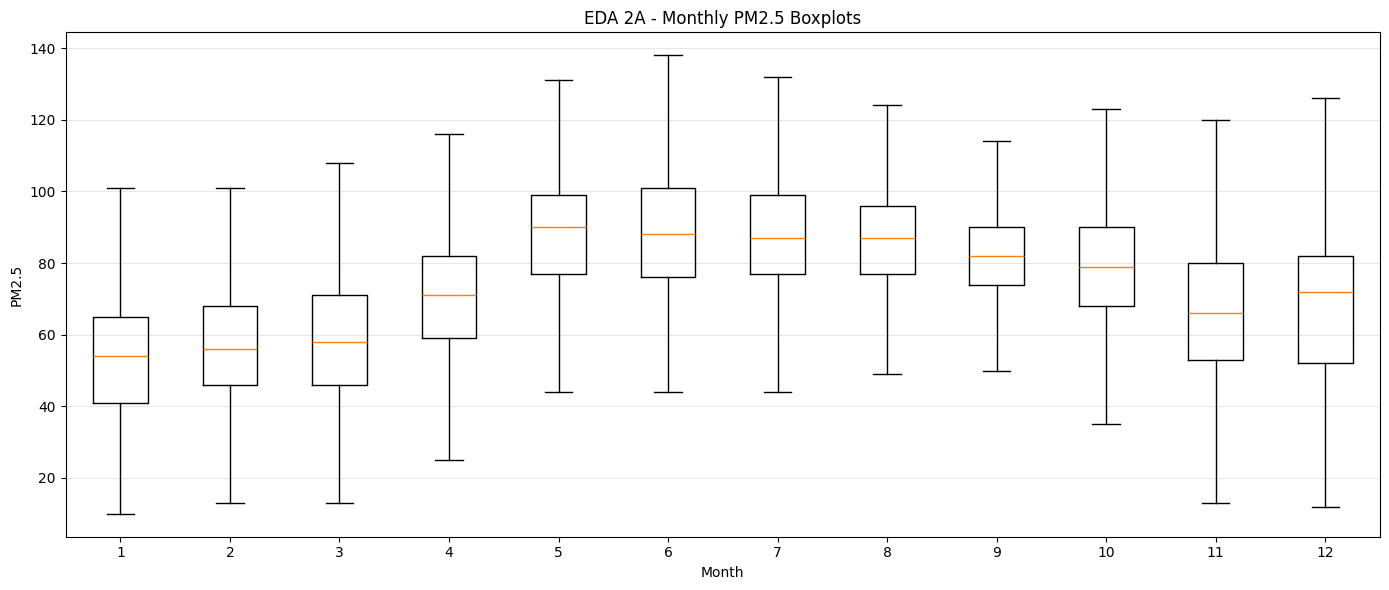

In [6]:
# =========================================================
# EDA 2: SEASONAL PATTERN
# Deliverable: eda_02_seasonal.png
# =========================================================

# split operasional dry vs wet
# wet  = Nov-Apr
# dry  = May-Oct
eda["season_simple"] = np.where(
    eda["month"].isin([11, 12, 1, 2, 3, 4]),
    "wet",
    "dry"
)

# monthly boxplot data
monthly_pm25 = [
    eda.loc[eda["month"] == m, "pm25"].dropna().values
    for m in range(1, 13)
]

plt.figure(figsize=(14, 6))
plt.boxplot(monthly_pm25, tick_labels=[str(m) for m in range(1, 13)], showfliers=False)
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.title("EDA 2A - Monthly PM2.5 Boxplots")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("eda_02_seasonal_monthly_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

## Perbandingan PM2.5 antara Musim Kering dan Musim Basah

Cell ini membandingkan distribusi PM2.5 antara dua kelompok musim sederhana, yaitu `dry` dan `wet`.

Nilai `dry_vals` berisi PM2.5 pada bulan Mei sampai Oktober, sedangkan `wet_vals` berisi PM2.5 pada bulan November sampai April.

Visualisasi dibuat menggunakan boxplot dua kelompok:

| Kelompok | Isi Data |
|---|---|
| `dry` | PM2.5 pada musim kering |
| `wet` | PM2.5 pada musim basah |

Output grafik disimpan sebagai:

`eda_02_seasonal_dry_vs_wet.png`

Grafik ini membantu menjawab apakah PM2.5 pada musim kering cenderung lebih tinggi dibanding musim basah. Jika perbedaannya jelas, maka informasi musim dapat menjadi fitur penting dalam model forecasting PM2.5.

Namun, karena pembagian wet/dry di sini masih sederhana berbasis bulan, interpretasinya perlu dianggap sebagai pendekatan operasional awal, bukan klasifikasi iklim yang sangat detail.

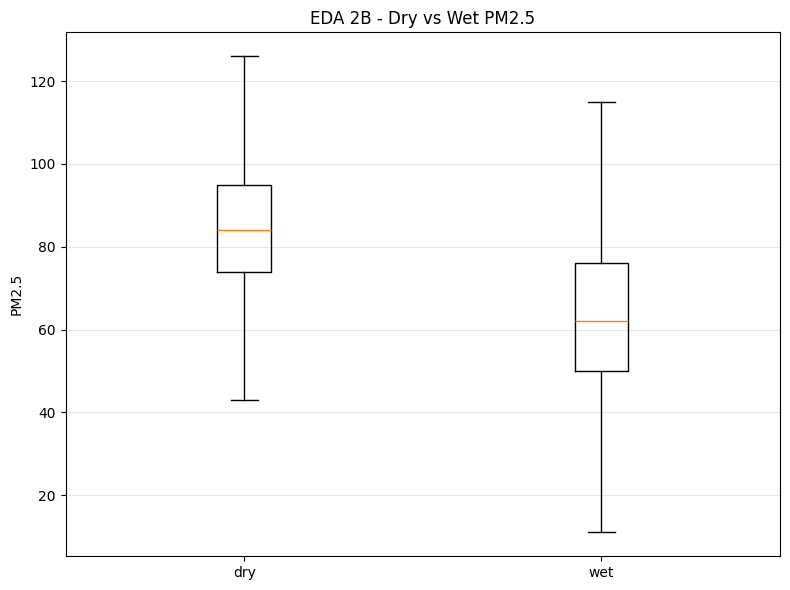

In [7]:
# dry vs wet boxplot
dry_vals = eda.loc[eda["season_simple"] == "dry", "pm25"].dropna().values
wet_vals = eda.loc[eda["season_simple"] == "wet", "pm25"].dropna().values

plt.figure(figsize=(8, 6))
plt.boxplot([dry_vals, wet_vals], tick_labels=["dry", "wet"], showfliers=False)
plt.ylabel("PM2.5")
plt.title("EDA 2B - Dry vs Wet PM2.5")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("eda_02_seasonal_dry_vs_wet.png", dpi=200, bbox_inches="tight")
plt.show()

## Rata-Rata PM2.5 per Bulan

Cell ini menghitung rata-rata PM2.5 untuk setiap bulan, kemudian menampilkannya dalam bentuk line plot.

Berbeda dengan boxplot yang memperlihatkan sebaran, grafik monthly mean fokus pada nilai rata-rata bulanan. Grafik ini lebih mudah digunakan untuk melihat arah naik-turun PM2.5 sepanjang tahun.

Langkah yang dilakukan:

1. Mengelompokkan data berdasarkan `month`.
2. Menghitung rata-rata `pm25`.
3. Mengurutkan bulan dari 1 sampai 12.
4. Membuat line plot dengan marker pada setiap bulan.

Output grafik disimpan sebagai:

`eda_02_seasonal_monthly_mean.png`

Grafik ini berguna untuk memperjelas pola seasonal. Jika rata-rata PM2.5 meningkat pada bulan-bulan tertentu, maka model forecasting perlu menangkap pola musiman tersebut melalui fitur waktu dan cuaca.

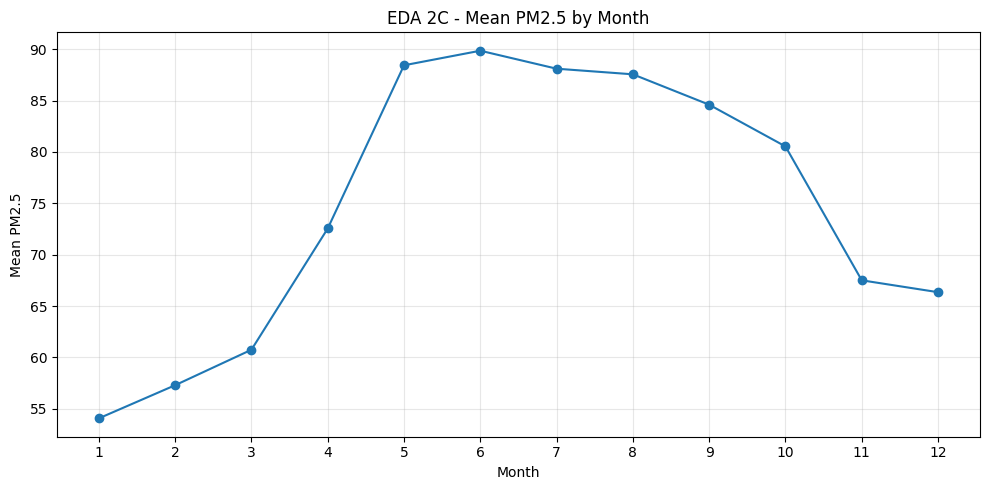

In [8]:
# optional: satu file ringkas line plot monthly mean
monthly_mean = (
    eda.groupby("month", as_index=False)["pm25"]
    .mean()
    .sort_values("month")
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_mean["month"], monthly_mean["pm25"], marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean PM2.5")
plt.title("EDA 2C - Mean PM2.5 by Month")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eda_02_seasonal_monthly_mean.png", dpi=200, bbox_inches="tight")
plt.show()

## Ringkasan Statistik PM2.5 per Stasiun

Cell ini membuat ringkasan statistik PM2.5 berdasarkan `station_slug`.

Statistik yang dihitung meliputi:

| Statistik | Makna |
|---|---|
| `n_obs` | Jumlah observasi PM2.5 yang tersedia |
| `pm25_mean` | Rata-rata PM2.5 |
| `pm25_median` | Median PM2.5 |
| `pm25_std` | Standar deviasi PM2.5 |
| `pm25_min` | Nilai minimum PM2.5 |
| `pm25_max` | Nilai maksimum PM2.5 |

Berdasarkan output, ringkasan per stasiun adalah sebagai berikut.

| Stasiun | n_obs | Mean | Median | Std | Min | Max |
|---|---:|---:|---:|---:|---:|---:|
| `dki1-bundaran-hi` | 16711 | 75.24 | 77.0 | 26.57 | 12.0 | 500.0 |
| `dki2-kelapa-gading` | 16866 | 72.50 | 75.0 | 21.45 | 10.0 | 140.0 |
| `dki3-jagakarsa` | 16824 | 70.88 | 71.0 | 16.53 | 13.0 | 152.0 |
| `dki4-lubang-buaya` | 16550 | 77.70 | 78.0 | 30.55 | 10.0 | 281.0 |
| `dki5-kebun-jeruk` | 13293 | 77.06 | 77.0 | 30.33 | 18.0 | 500.0 |

Dari tabel ini terlihat bahwa `dki4-lubang-buaya` memiliki rata-rata PM2.5 tertinggi, sedangkan `dki3-jagakarsa` memiliki rata-rata PM2.5 terendah.

Nilai maksimum 500 pada beberapa stasiun perlu diperhatikan karena sebelumnya data sudah dibatasi menggunakan `clip(upper=500)`. Artinya, nilai 500 dapat merepresentasikan nilai yang memang 500 atau nilai ekstrem yang dipotong menjadi 500.

In [9]:
# =========================
# QUICK SUMMARY
# =========================
summary_station = (
    eda.groupby("station_slug", as_index=False)
    .agg(
        n_obs=("pm25", "size"),
        pm25_mean=("pm25", "mean"),
        pm25_median=("pm25", "median"),
        pm25_std=("pm25", "std"),
        pm25_min=("pm25", "min"),
        pm25_max=("pm25", "max")
    )
)

print("\n=== SUMMARY PER STATION ===")
print(summary_station)


=== SUMMARY PER STATION ===
         station_slug  n_obs  pm25_mean  pm25_median   pm25_std  pm25_min  \
0    dki1-bundaran-hi  16711  75.241757         77.0  26.570741      12.0   
1  dki2-kelapa-gading  16866  72.500474         75.0  21.445648      10.0   
2      dki3-jagakarsa  16824  70.884510         71.0  16.526966      13.0   
3   dki4-lubang-buaya  16550  77.699577         78.0  30.548874      10.0   
4    dki5-kebun-jeruk  13293  77.059355         77.0  30.326380      18.0   

   pm25_max  
0     500.0  
1     140.0  
2     152.0  
3     281.0  
4     500.0  


# EDA PM2.5 dengan Interpolasi untuk Visualisasi

Bagian ini melakukan EDA PM2.5 menggunakan versi data yang sudah dibuat lebih utuh secara visual.

Strategi yang digunakan adalah:

1. Missing value di tengah deret waktu diisi dengan interpolasi linear.
2. Missing value di awal atau akhir deret waktu diisi menggunakan backward fill dan forward fill.
3. Hasil filling disimpan pada kolom baru bernama `pm25_viz`.
4. Kolom asli `pm25` tetap dipertahankan agar data asli dan data hasil filling tidak tercampur.

Pendekatan ini bertujuan untuk membantu visualisasi pola PM2.5, terutama pola harian dan musiman, agar tidak terlalu terputus karena missing value.

Catatan penting: kolom `pm25_viz` sebaiknya diperlakukan sebagai variabel untuk visualisasi. Untuk modeling, perlu strategi validasi yang lebih ketat agar proses imputasi tidak menyebabkan leakage atau bias.

## Membuat Versi PM2.5 yang Lebih Utuh untuk Visualisasi

Cell ini membaca ulang dataset master dan membuat kolom baru bernama `pm25_viz`.

Kolom `pm25_viz` dibuat dari `pm25` dengan strategi berikut:

| Kondisi Missing | Strategi |
|---|---|
| Missing di tengah deret waktu | Diisi dengan interpolasi linear |
| Missing di awal deret waktu | Diisi dengan backward fill |
| Missing di akhir deret waktu | Diisi dengan forward fill |

Proses filling dilakukan per stasiun menggunakan:

`groupby("station_slug")`

Hal ini penting karena data PM2.5 setiap stasiun memiliki pola dan level yang berbeda. Jika filling dilakukan tanpa memisahkan stasiun, nilai dari satu stasiun bisa memengaruhi stasiun lain.

Cell ini juga membuat kolom:

`pm25_was_missing`

Kolom tersebut berisi penanda apakah nilai PM2.5 asli pada baris tersebut awalnya missing atau tidak.

Output menunjukkan:

| Informasi | Nilai |
|---|---:|
| Missing PM2.5 asli | 0.485219 |
| Missing PM2.5 setelah filling | 0.0 |
| Jumlah baris PM2.5 asli missing | 75636 |
| Jumlah baris PM2.5 setelah fill yang masih missing | 0 |

Ringkasan per stasiun menunjukkan bahwa semua missing value berhasil diisi pada kolom `pm25_viz`.

Namun, hasil filling ini perlu dibaca sebagai bantuan visualisasi. Karena hampir separuh data PM2.5 awalnya missing, interpretasi dari grafik filled harus tetap dibandingkan dengan grafik observed only.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) LOAD DATA
# =========================
DATA_PATH = "dataset_master_spku_weather.csv"   # ganti jika perlu
df = pd.read_csv(DATA_PATH)

# =========================
# 2) BASIC CLEANING
# =========================
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

num_cols = [
    "pm25", "pm10", "so2", "co", "o3", "no2",
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "rain", "surface_pressure",
    "wind_speed_10m", "wind_direction_10m"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        
df["pm25"] = df["pm25"].clip(upper=500)

if "hour_num" not in df.columns:
    df["hour_num"] = df["datetime"].dt.hour

if "month" not in df.columns:
    df["month"] = df["datetime"].dt.month

if "dayofweek" not in df.columns:
    df["dayofweek"] = df["datetime"].dt.dayofweek

if "is_weekend" not in df.columns:
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    
# =========================
# 3) PM2.5 VISUAL IMPUTATION
#    per station:
#    - interpolate internal missing
#    - bfill/ffill untuk missing di tepi
# =========================
df = df.sort_values(["station_slug", "datetime"]).reset_index(drop=True)

def fill_pm25_for_visual(series):
    s = series.copy()

    # isi missing yang berada di tengah
    s = s.interpolate(method="linear", limit_area="inside")

    # isi missing di awal/akhir
    s = s.bfill().ffill()

    return s

df["pm25_viz"] = (
    df.groupby("station_slug", group_keys=False)["pm25"]
      .apply(fill_pm25_for_visual)
)

df["pm25_was_missing"] = df["pm25"].isna().astype(int)

print("=== MISSING CHECK ===")
print("Missing pm25 asli     :", df["pm25"].isna().mean())
print("Missing pm25_viz      :", df["pm25_viz"].isna().mean())
print("Rows originally null  :", df["pm25"].isna().sum())
print("Rows after fill null  :", df["pm25_viz"].isna().sum())

summary_fill = (
    df.groupby("station_slug", as_index=False)
      .agg(
          n_rows=("datetime", "size"),
          pm25_missing_before=("pm25", lambda s: s.isna().sum()),
          pm25_missing_after=("pm25_viz", lambda s: s.isna().sum()),
      )
)

print("\n=== SUMMARY FILL PER STATION ===")
print(summary_fill)

=== MISSING CHECK ===
Missing pm25 asli     : 0.4852193995381062
Missing pm25_viz      : 0.0
Rows originally null  : 75636
Rows after fill null  : 0

=== SUMMARY FILL PER STATION ===
         station_slug  n_rows  pm25_missing_before  pm25_missing_after
0    dki1-bundaran-hi   31176                14465                   0
1  dki2-kelapa-gading   31176                14310                   0
2      dki3-jagakarsa   31176                14352                   0
3   dki4-lubang-buaya   31176                14626                   0
4    dki5-kebun-jeruk   31176                17883                   0


## Membandingkan PM2.5 Asli dan PM2.5 Hasil Filling

Cell ini mengambil satu contoh stasiun, lalu membandingkan nilai PM2.5 asli dengan nilai PM2.5 hasil filling pada kolom `pm25_viz`.

Visualisasi menggunakan dua bentuk:

| Elemen Grafik | Makna |
|---|---|
| Garis `pm25_viz` | Deret waktu PM2.5 setelah missing value diisi |
| Titik `pm25` asli | Nilai PM2.5 yang benar-benar tersedia dari data asli |

Tujuan grafik ini adalah memastikan bahwa proses filling tidak menghilangkan pola utama dari data asli. Titik-titik data asli tetap ditampilkan agar pembaca bisa membedakan mana data observasi dan mana data hasil interpolasi/filling.

Grafik ini penting karena jika garis hasil filling terlalu menyimpang dari titik asli, maka metode filling perlu dievaluasi kembali.

Pada konteks notebook ini, visualisasi tersebut digunakan sebagai sanity check sebelum grafik diurnal dan seasonal dibuat ulang menggunakan `pm25_viz`.

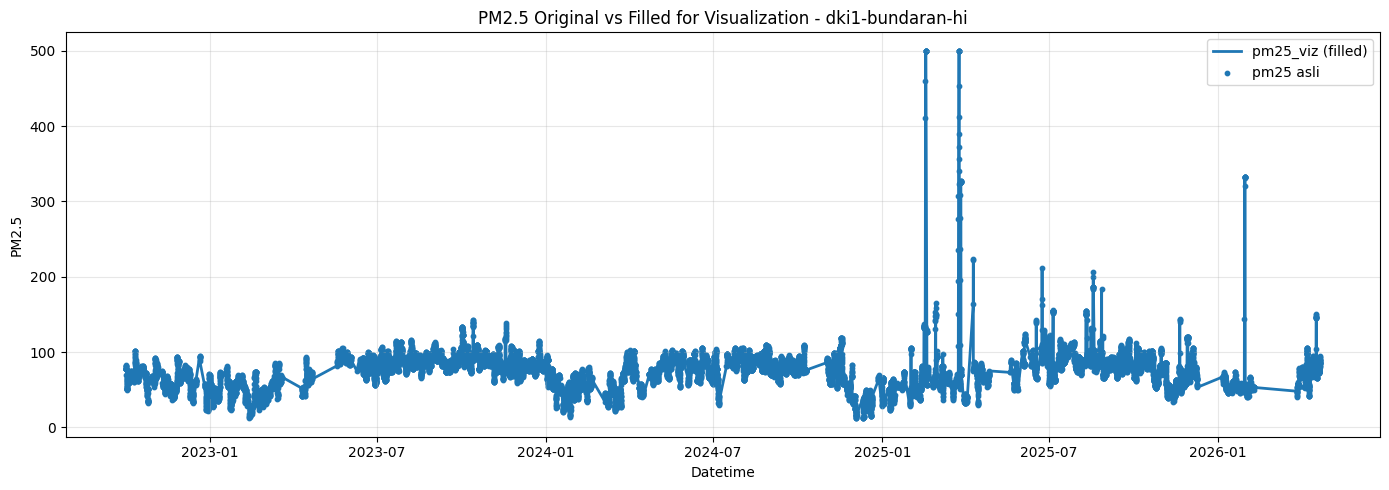

In [11]:
sample_station = df["station_slug"].dropna().unique()[0]
sample_df = df[df["station_slug"] == sample_station].copy()

plt.figure(figsize=(14, 5))
plt.plot(sample_df["datetime"], sample_df["pm25_viz"], label="pm25_viz (filled)", linewidth=2)
plt.scatter(sample_df["datetime"], sample_df["pm25"], label="pm25 asli", s=10)
plt.title(f"PM2.5 Original vs Filled for Visualization - {sample_station}")
plt.xlabel("Datetime")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Diurnal Cycle dengan PM2.5 Hasil Filling

Cell ini membuat ulang grafik diurnal cycle, tetapi kali ini menggunakan kolom `pm25_viz`.

Perbedaannya dengan grafik observed only adalah:

| Versi | Kolom yang Dipakai | Karakter Grafik |
|---|---|---|
| Observed only | `pm25` | Berdasarkan data asli yang tersedia |
| Visual filled | `pm25_viz` | Lebih halus dan tidak terputus karena missing sudah diisi |

Grafik tetap menghitung dua pola:

1. Rata-rata PM2.5 per jam untuk seluruh stasiun.
2. Rata-rata PM2.5 per jam untuk masing-masing stasiun.

Output grafik disimpan sebagai:

`eda_01_diurnal_filled.png`

Jika pola pada grafik filled masih sama dengan grafik observed only, maka kesimpulan diurnal dapat dianggap lebih stabil. Namun jika pola berubah drastis, maka missing value memiliki pengaruh besar terhadap interpretasi pola harian.

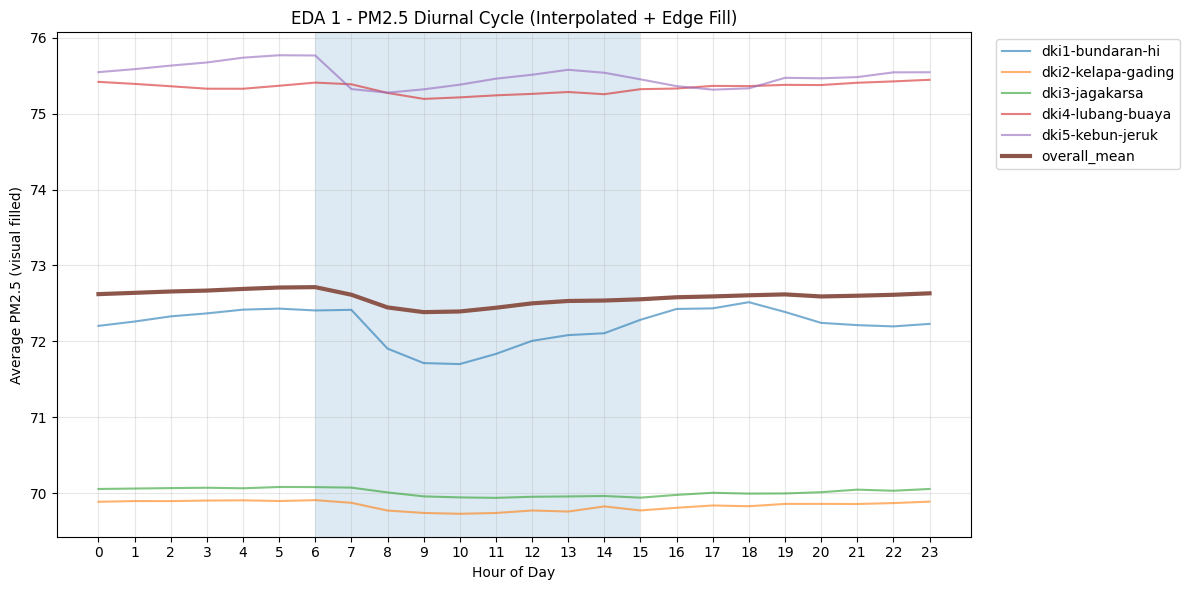

In [12]:
eda = df.dropna(subset=["pm25_viz"]).copy()

hourly_overall = (
    eda.groupby("hour_num", as_index=False)["pm25_viz"]
       .mean()
       .sort_values("hour_num")
)

hourly_station = (
    eda.groupby(["station_slug", "hour_num"], as_index=False)["pm25_viz"]
       .mean()
       .sort_values(["station_slug", "hour_num"])
)

plt.figure(figsize=(12, 6))

for station, g in hourly_station.groupby("station_slug"):
    plt.plot(g["hour_num"], g["pm25_viz"], linewidth=1.5, alpha=0.6, label=station)

plt.plot(
    hourly_overall["hour_num"],
    hourly_overall["pm25_viz"],
    linewidth=3,
    label="overall_mean"
)

# overlay jam sekolah / jam aktivitas
plt.axvspan(6, 15, alpha=0.15)

plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5 (visual filled)")
plt.title("EDA 1 - PM2.5 Diurnal Cycle (Interpolated + Edge Fill)")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("eda_01_diurnal_filled.png", dpi=200, bbox_inches="tight")
plt.show()

## Boxplot Bulanan PM2.5 Setelah Visual Filling

Cell ini membuat ulang boxplot bulanan menggunakan `pm25_viz`.

Tujuannya adalah membandingkan apakah pola seasonal tetap terlihat setelah missing value diisi. Dengan data yang lebih utuh, boxplot dapat memberikan gambaran yang lebih lengkap tentang distribusi PM2.5 per bulan.

Output grafik disimpan sebagai:

`eda_02_seasonal_monthly_boxplot_filled.png`

Boxplot ini tetap menggunakan `showfliers=False`, sehingga outlier ekstrem tidak ditampilkan agar distribusi utama lebih mudah dibaca.

Jika pola median bulanan pada versi filled mirip dengan observed only, maka seasonal pattern dapat dianggap cukup konsisten. Namun, karena `pm25_viz` mengandung nilai hasil interpolasi, grafik ini sebaiknya digunakan sebagai pembanding, bukan satu-satunya dasar kesimpulan.

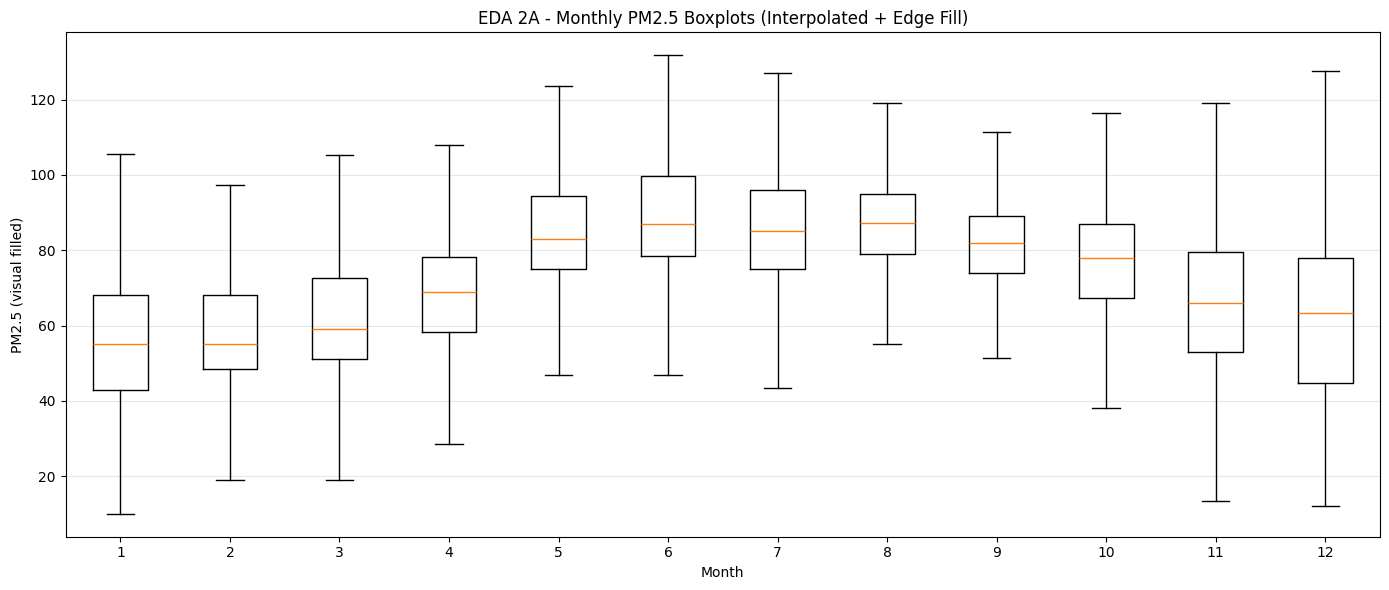

In [13]:
eda["season_simple"] = np.where(
    eda["month"].isin([11, 12, 1, 2, 3, 4]),
    "wet",
    "dry"
)

# 2A - monthly boxplot
monthly_pm25 = [
    eda.loc[eda["month"] == m, "pm25_viz"].dropna().values
    for m in range(1, 13)
]

plt.figure(figsize=(14, 6))
plt.boxplot(monthly_pm25, tick_labels=[str(m) for m in range(1, 13)], showfliers=False)
plt.xlabel("Month")
plt.ylabel("PM2.5 (visual filled)")
plt.title("EDA 2A - Monthly PM2.5 Boxplots (Interpolated + Edge Fill)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("eda_02_seasonal_monthly_boxplot_filled.png", dpi=200, bbox_inches="tight")
plt.show()

## Perbandingan Musim Kering dan Basah Setelah Visual Filling

Cell ini membandingkan PM2.5 antara musim `dry` dan `wet` menggunakan kolom `pm25_viz`.

Kelompok musim tetap menggunakan definisi sederhana:

| Musim | Bulan |
|---|---|
| `dry` | Mei sampai Oktober |
| `wet` | November sampai April |

Output grafik disimpan sebagai:

`eda_02_seasonal_dry_vs_wet_filled.png`

Grafik ini membantu melihat apakah perbedaan PM2.5 antara musim kering dan musim basah tetap bertahan setelah missing value diisi.

Jika musim kering tetap menunjukkan PM2.5 yang lebih tinggi, maka indikasi seasonal pattern semakin kuat. Namun, interpretasi tetap perlu hati-hati karena sebagian nilai pada `pm25_viz` adalah hasil imputasi visual.

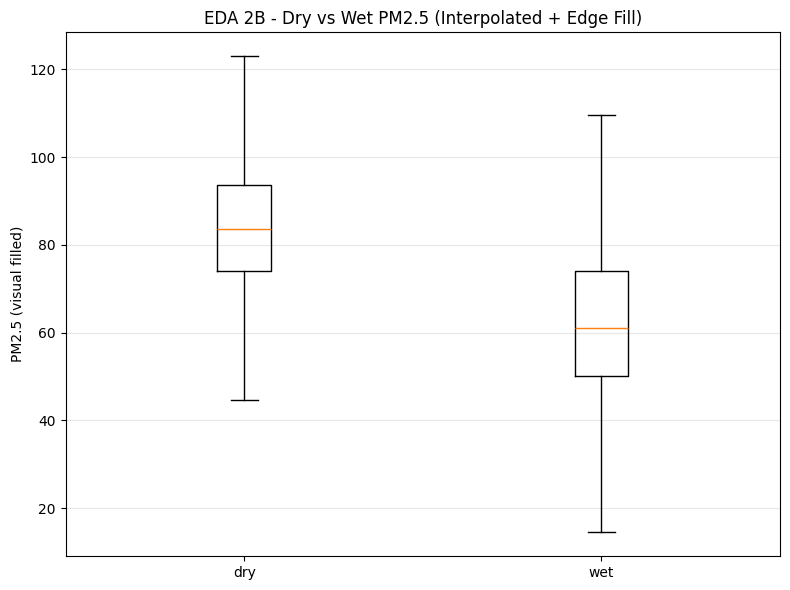

In [14]:
# 2B - dry vs wet
dry_vals = eda.loc[eda["season_simple"] == "dry", "pm25_viz"].dropna().values
wet_vals = eda.loc[eda["season_simple"] == "wet", "pm25_viz"].dropna().values

plt.figure(figsize=(8, 6))
plt.boxplot([dry_vals, wet_vals], tick_labels=["dry", "wet"], showfliers=False)
plt.ylabel("PM2.5 (visual filled)")
plt.title("EDA 2B - Dry vs Wet PM2.5 (Interpolated + Edge Fill)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("eda_02_seasonal_dry_vs_wet_filled.png", dpi=200, bbox_inches="tight")
plt.show()

## Rata-Rata Bulanan PM2.5 Setelah Visual Filling

Cell ini menghitung rata-rata bulanan PM2.5 menggunakan kolom `pm25_viz`.

Grafik ini merupakan versi filled dari monthly mean plot sebelumnya. Tujuannya adalah melihat apakah arah tren bulanan tetap sama ketika missing value diisi.

Output grafik disimpan sebagai:

`eda_02_seasonal_monthly_mean_filled.png`

Grafik ini berguna untuk menguatkan pembacaan pola musiman. Jika rata-rata bulanan tetap naik pada pertengahan tahun dan turun pada awal/akhir tahun, maka fitur `month`, `season_simple`, dan variabel cuaca perlu dipertimbangkan dalam modeling.

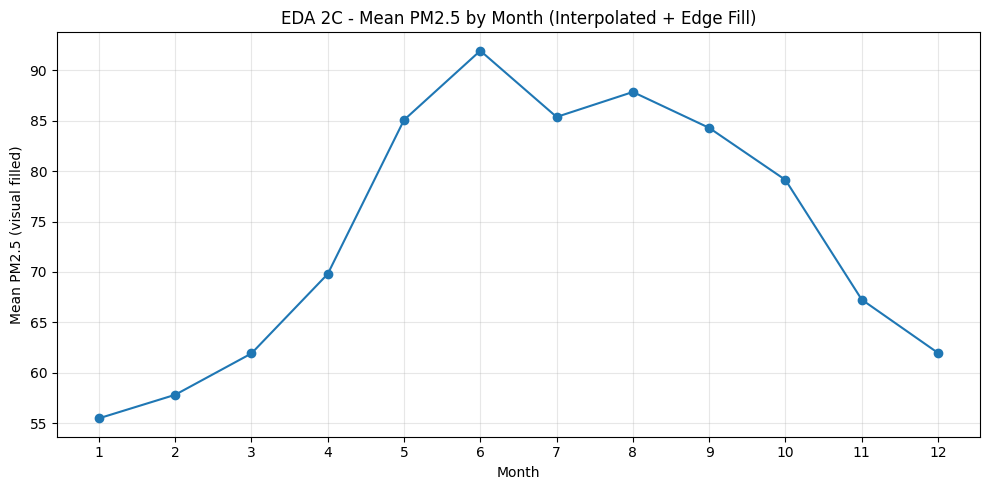

In [15]:
monthly_mean = (
    eda.groupby("month", as_index=False)["pm25_viz"]
       .mean()
       .sort_values("month")
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_mean["month"], monthly_mean["pm25_viz"], marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean PM2.5 (visual filled)")
plt.title("EDA 2C - Mean PM2.5 by Month (Interpolated + Edge Fill)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eda_02_seasonal_monthly_mean_filled.png", dpi=200, bbox_inches="tight")
plt.show()

## Membandingkan Missing Value Sebelum dan Sesudah Filling

Cell ini membandingkan missing ratio PM2.5 sebelum dan sesudah proses filling pada setiap stasiun.

Dua tabel yang dibuat adalah:

| Tabel | Kolom yang Dicek |
|---|---|
| `missing_before_station` | Missing ratio dari `pm25` asli |
| `missing_after_station` | Missing ratio dari `pm25_viz` setelah filling |

Kedua tabel kemudian digabung menjadi `missing_compare`.

In [16]:
missing_before_station = (
    df.groupby("station_slug")["pm25"]
      .apply(lambda s: s.isna().mean())
      .reset_index(name="missing_ratio_before")
)

missing_after_station = (
    df.groupby("station_slug")["pm25_viz"]
      .apply(lambda s: s.isna().mean())
      .reset_index(name="missing_ratio_after")
)

missing_compare = missing_before_station.merge(
    missing_after_station,
    on="station_slug",
    how="left"
)

print("\n=== MISSING RATIO BEFORE VS AFTER ===")
print(missing_compare)


=== MISSING RATIO BEFORE VS AFTER ===
         station_slug  missing_ratio_before  missing_ratio_after
0    dki1-bundaran-hi              0.463979                  0.0
1  dki2-kelapa-gading              0.459007                  0.0
2      dki3-jagakarsa              0.460354                  0.0
3   dki4-lubang-buaya              0.469143                  0.0
4    dki5-kebun-jeruk              0.573614                  0.0


# Interpretasi Pola Harian PM2.5

Hasil EDA menunjukkan bahwa PM2.5 memiliki pola harian atau **diurnal cycle** yang cukup jelas. Artinya, waktu dalam sehari berpengaruh terhadap perubahan level PM2.5.

Beberapa temuan utama dari grafik diurnal adalah:

| Temuan | Interpretasi |
|---|---|
| PM2.5 cenderung rendah pada dini hari | Aktivitas manusia dan lalu lintas relatif lebih rendah |
| PM2.5 mulai meningkat pada pagi hari | Kemungkinan berkaitan dengan peningkatan aktivitas harian dan mobilitas |
| PM2.5 relatif stabil pada siang hingga sore | Pola pencampuran atmosfer dan aktivitas harian mulai seimbang |
| PM2.5 kembali cukup tinggi pada malam hari | Polutan dapat terakumulasi ketika kondisi atmosfer lebih stabil |
| Kurva antarstasiun berbeda | Identitas stasiun memengaruhi level PM2.5 |

Secara umum, rata-rata PM2.5 berada pada level yang cukup tinggi. Perbedaan antarstasiun juga terlihat jelas, sehingga lokasi pengamatan perlu diperlakukan sebagai informasi penting dalam modeling.

Stasiun seperti `dki4-lubang-buaya` dan `dki5-kebun-jeruk` cenderung memiliki level PM2.5 yang tinggi, sedangkan `dki3-jagakarsa` relatif lebih rendah dibanding stasiun lainnya.

Versi visual filled mempertahankan pola umum yang mirip dengan versi observed only, tetapi kurvanya menjadi lebih halus karena missing value sudah diisi. Hal ini menunjukkan bahwa kesimpulan pola harian cukup stabil, meskipun tetap perlu hati-hati karena sebagian data pada versi filled merupakan hasil interpolasi.

Implikasi untuk modeling:

1. Fitur `hour_num` penting untuk menangkap pola harian.
2. Fitur indikator jam aktivitas atau rush hour dapat dipertimbangkan.
3. Fitur lag jangka pendek relevan karena PM2.5 memiliki pola temporal.
4. `station_slug` perlu digunakan karena level PM2.5 berbeda antarstasiun.

# Interpretasi Pola Musiman PM2.5

Hasil EDA menunjukkan bahwa PM2.5 memiliki pola musiman atau **seasonal pattern** yang kuat. Level PM2.5 tidak seragam sepanjang tahun, tetapi berubah mengikuti periode bulan dan musim.

Berdasarkan boxplot dry vs wet, musim kering memiliki PM2.5 yang lebih tinggi dibanding musim basah. Hal ini masuk akal karena pada musim basah, hujan dapat membantu menurunkan konsentrasi polutan melalui proses deposisi basah. Sebaliknya, pada musim kering, polutan lebih mudah bertahan dan terakumulasi di udara.

Temuan utama dari pola musiman adalah:

| Temuan | Interpretasi |
|---|---|
| PM2.5 lebih tinggi pada musim kering | Polutan lebih mudah terakumulasi ketika hujan lebih sedikit |
| PM2.5 lebih rendah pada musim basah | Hujan dapat membantu membersihkan partikel dari udara |
| Pertengahan tahun cenderung lebih tinggi | Periode Mei sampai Agustus menjadi periode penting untuk diperhatikan |
| Awal dan akhir tahun cenderung lebih rendah | Periode ini lebih dekat dengan musim basah |
| Pola monthly mean dan boxplot saling mendukung | Seasonal pattern terlihat konsisten dari beberapa visualisasi |

Monthly mean menunjukkan bahwa PM2.5 cenderung naik dari awal tahun menuju pertengahan tahun, kemudian menurun kembali menjelang akhir tahun.

Versi interpolated + edge fill tidak mengubah arah kesimpulan utama. Pola besarnya tetap sama, yaitu PM2.5 lebih rendah pada awal dan akhir tahun, lalu lebih tinggi pada pertengahan tahun.

Implikasi untuk modeling:

1. Fitur `month` penting untuk menangkap pola musiman.
2. Fitur `season_simple` dapat digunakan sebagai indikator musim.
3. Variabel cuaca seperti `rain`, `precipitation`, `relative_humidity_2m`, dan `wind_speed_10m` perlu dipertimbangkan.
4. Evaluasi model sebaiknya berbasis waktu agar model diuji pada periode seasonal yang berbeda.

# Kesimpulan EDA PM2.5

Berdasarkan notebook ini, data PM2.5 pada lima stasiun Jakarta memiliki tiga karakter penting: missing value yang besar, pola harian yang jelas, dan pola musiman yang kuat.

Pertama, missing value pada `pm25` cukup besar, yaitu sekitar **48,52%** dari total data. Missing value juga tidak tersebar merata, karena ada perbedaan antarstasiun, antarjam, dan antarbulan. Hal ini menunjukkan bahwa missing value perlu diperlakukan sebagai isu metodologis penting sebelum modeling.

Kedua, pola harian menunjukkan bahwa PM2.5 berubah mengikuti jam dalam sehari. PM2.5 cenderung meningkat pada pagi hari, relatif stabil pada siang hingga sore, dan tetap cukup tinggi pada malam hari. Dengan demikian, fitur berbasis jam dan lag jangka pendek relevan untuk forecasting.

Ketiga, pola musiman menunjukkan bahwa PM2.5 lebih tinggi pada musim kering dibanding musim basah. Periode pertengahan tahun cenderung memiliki level PM2.5 lebih tinggi, sedangkan awal dan akhir tahun cenderung lebih rendah.

Keempat, perbedaan antarstasiun cukup jelas. Beberapa stasiun memiliki rata-rata PM2.5 lebih tinggi dibanding stasiun lain. Oleh karena itu, `station_slug` atau identitas lokasi perlu dimasukkan sebagai fitur penting dalam pipeline modeling.

Ringkasan implikasi untuk tahap berikutnya:

| Aspek | Implikasi untuk Modeling |
|---|---|
| Missing value tinggi | Perlu strategi imputasi atau filtering yang jelas |
| Pola harian kuat | Gunakan fitur `hour_num`, rush hour, dan lag |
| Pola musiman kuat | Gunakan fitur `month`, `season_simple`, dan weather |
| Perbedaan antarstasiun jelas | Gunakan `station_slug` sebagai fitur kategorikal |
| Data time series | Split data sebaiknya berbasis waktu, bukan random |

Secara keseluruhan, notebook ini menunjukkan bahwa dataset memiliki sinyal temporal yang kuat dan layak dilanjutkan ke tahap feature engineering serta baseline forecasting PM2.5.

# Struktur File Output Notebook

Notebook ini tidak membuat folder output khusus. Semua file gambar hasil EDA disimpan langsung di working directory notebook.

Input utama yang digunakan adalah:

```text
dataset_master_spku_weather.csv
```

File output yang dihasilkan dari visualisasi observed only adalah:

```text
eda_01_diurnal.png
eda_02_seasonal_monthly_boxplot.png
eda_02_seasonal_dry_vs_wet.png
eda_02_seasonal_monthly_mean.png
```

File output yang dihasilkan dari visualisasi interpolated + edge fill adalah:

```text
eda_01_diurnal_filled.png
eda_02_seasonal_monthly_boxplot_filled.png
eda_02_seasonal_dry_vs_wet_filled.png
eda_02_seasonal_monthly_mean_filled.png
```

Struktur output notebook dapat diringkas sebagai berikut:

```text
project/
│
├── dataset_master_spku_weather.csv
│
├── eda_01_diurnal.png
├── eda_02_seasonal_monthly_boxplot.png
├── eda_02_seasonal_dry_vs_wet.png
├── eda_02_seasonal_monthly_mean.png
│
├── eda_01_diurnal_filled.png
├── eda_02_seasonal_monthly_boxplot_filled.png
├── eda_02_seasonal_dry_vs_wet_filled.png
└── eda_02_seasonal_monthly_mean_filled.png
```

Penjelasan setiap file output:

| File | Isi |
|---|---|
| `eda_01_diurnal.png` | Grafik pola harian PM2.5 berdasarkan data asli yang tersedia |
| `eda_02_seasonal_monthly_boxplot.png` | Boxplot PM2.5 per bulan berdasarkan data asli |
| `eda_02_seasonal_dry_vs_wet.png` | Perbandingan PM2.5 musim kering dan musim basah berdasarkan data asli |
| `eda_02_seasonal_monthly_mean.png` | Rata-rata PM2.5 per bulan berdasarkan data asli |
| `eda_01_diurnal_filled.png` | Grafik pola harian PM2.5 setelah visual filling |
| `eda_02_seasonal_monthly_boxplot_filled.png` | Boxplot bulanan PM2.5 setelah visual filling |
| `eda_02_seasonal_dry_vs_wet_filled.png` | Perbandingan dry vs wet setelah visual filling |
| `eda_02_seasonal_monthly_mean_filled.png` | Rata-rata bulanan PM2.5 setelah visual filling |

File visualisasi yang paling penting untuk dilampirkan dalam laporan adalah:

1. `eda_01_diurnal.png`
2. `eda_02_seasonal_dry_vs_wet.png`
3. `eda_02_seasonal_monthly_mean.png`
4. `eda_01_diurnal_filled.png`

Keempat file tersebut sudah cukup mewakili pola harian, pola musiman, dan perbandingan antara data asli dengan data hasil filling untuk visualisasi.